# Smoothing-Strength Sweep for `local_patch_cross_terms` Sub-Experiment

## Motivation

`embeddings.py::local_patch_cross_terms` (spatial 3x3-neighbor pixel products) previously failed
Mahalanobis epsilon selection *categorically*: every one of the 7 standard epsilon candidates
produced a coefficient of variation (cv) of 0.91-1.45, an order of magnitude past the `cv<=0.05`
stability bound (`README.md`'s "Epsilon selection fails categorically for this embedding"
section). A working (not yet independently verified) hypothesis there was that MNIST's mostly-black
background makes cross-term features near-zero everywhere except the stroke, so the per-subsample
covariance is dominated by which few pixels happen to be "on" in that particular subsample, rather
than a stable population-level structure.

This notebook tests a direct fix: apply a Gaussian blur to the raw image *before* computing
cross-terms (`smoothing.py::smoothed_cross_terms_embedding`), so more pixels are non-zero and the
covariance has more to work with. **The obvious risk**: too much blur makes different digits look
alike, destroying the very margin-sensitivity signal this whole project measures. So smoothing
strength (`sigma`) is swept, not picked once -- `sigma` in `{0, 0.5, 1, 1.5, 2, 3}`, where
`sigma=0` is an exact identity (no blur), reproducing the already-documented unblurred
`local_patch_cross_terms` result as this sweep's own baseline row, not a fresh comparison.

## What this notebook does

Thin driver only -- all reusable logic lives in `smoothing.py` (the blur + composition helper) and
`run_experiment.py::run_smoothing_sweep` (the sweep driver, mirroring
`run_embedding_degree_sweep`'s established structure). For each `sigma`, `run_smoothing_sweep`:

1. Runs the same `epsilon_stability_check` used everywhere else in this project, over the same
   standard 7-candidate epsilon sweep, to see whether blurring fixes the categorical instability.
2. Runs the full near-neighbor vs. all-pairs ratio-distribution analysis for
   `smoothed_cross_terms_embedding` + Euclidean distance (always) and + Mahalanobis distance
   (**only** when epsilon stability actually passes at that sigma -- computing an expensive
   full-60k-point Mahalanobis fit on top of an epsilon that never met the stability bound would
   just repeat the same "not a reliable estimate" caveat already documented for the unblurred
   embedding's fallback-epsilon result).
3. Computes `knn_label_purity` (this project's standard embedding-quality check, see
   `umap_embedding.py`/`notebook_umap.ipynb`) on a fixed validation subset.
4. Renders a visual gallery of a handful of sample digits, original vs. blurred at that sigma, to
   directly check the "digits still distinguishable?" risk.

**Note on point counts**: `local_patch_cross_terms`'s 3920-dimensional output already exhausted
this machine's memory/swap at 1000 ratio-distribution points in an earlier one-off comparison
(`results/local_patch_cross_terms_euclidean_followup.md`). This sweep repeats that embedding's
memory footprint up to 6 times (once per sigma), so `run_smoothing_sweep` defaults its
ratio-distribution point count to 300 preemptively, rather than discovering the same ceiling 6
times over -- see its docstring for the full reasoning.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import torch
torch.set_default_dtype(torch.float64)

from mnist_lipschitz.run_experiment import run_smoothing_sweep

SEED = 0

## Run the sweep

Trains its own reference logistic-regression model (same convention as `notebook_umap.ipynb`),
then sweeps `sigma` in `{0, 0.5, 1, 1.5, 2, 3}` at the standard 7-candidate epsilon grid. This is
the expensive cell in this notebook -- 6 sigmas, each repeating a full epsilon-selection stability
check (7 epsilons x 5 subsamples) plus at least one full ratio-distribution analysis (more if
Mahalanobis passes stability at that sigma).

  epoch  1/15  train loss 0.8430


  epoch  2/15  train loss 0.4254


  epoch  3/15  train loss 0.3603


  epoch  4/15  train loss 0.3299


  epoch  5/15  train loss 0.3119


...

  epsilon=1          mean L_hat=153161618.0481  std=53077124.3525  cv=0.3465


  epsilon=10         mean L_hat=461549970.2839  std=70472242.9367  cv=0.1527


  epsilon=100        mean L_hat=1390363406.2185  std=183252354.0874  cv=0.1318


  [smoothing_sigma3_euclidean/logistic_regression] all-pairs ratio:        mean=0.8084  max=9.9194  n=44850
  [smoothing_sigma3_euclidean/logistic_regression] near-neighbor ratio:     mean=1.1138  max=9.9194  n=1500
  sigma=3: epsilon stability did not pass (min cv=0.1241 > 0.05) -- skipping Mahalanobis ratio-distribution



Saved results to /Users/swarn2/Downloads/Datasig-1/mnist_lipschitz/results

done


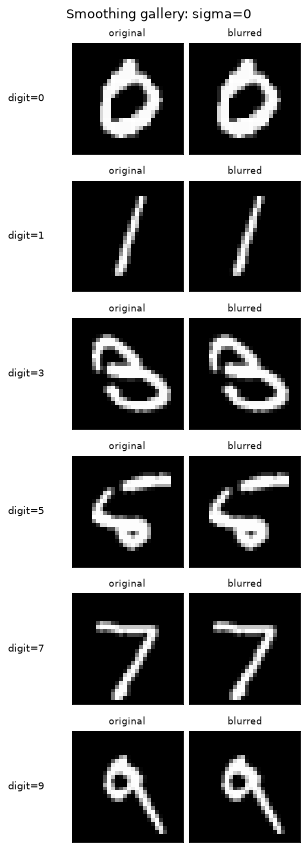

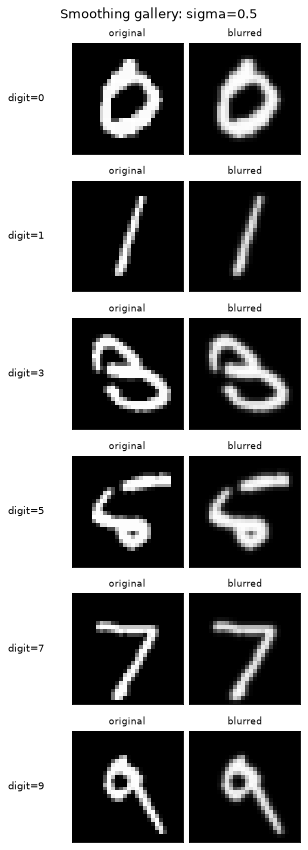

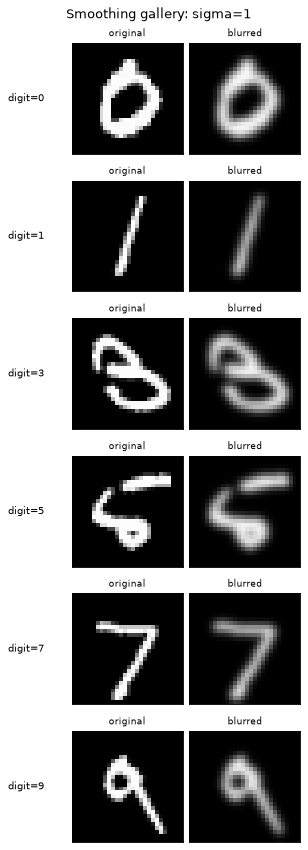

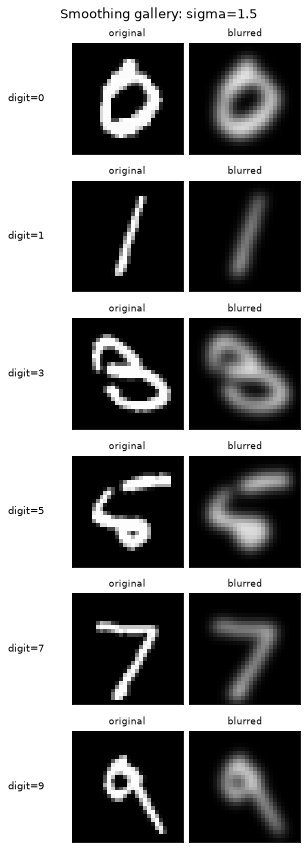

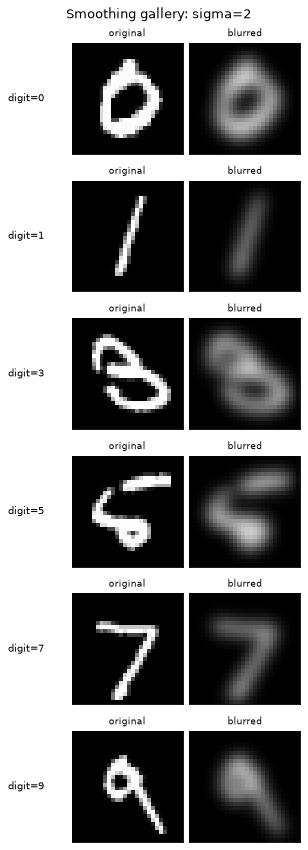

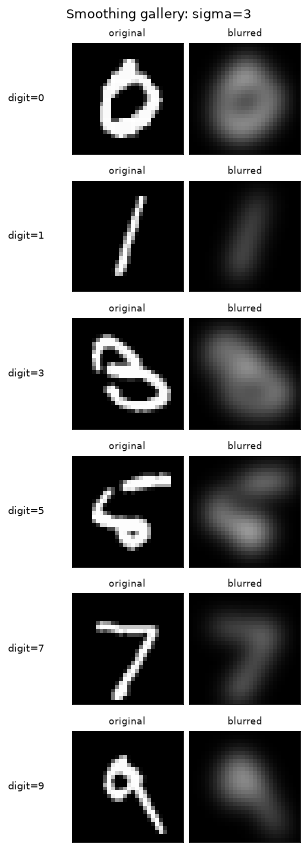

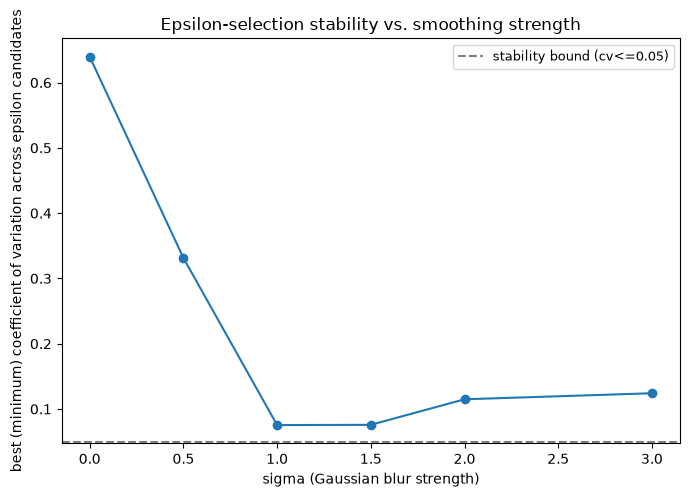

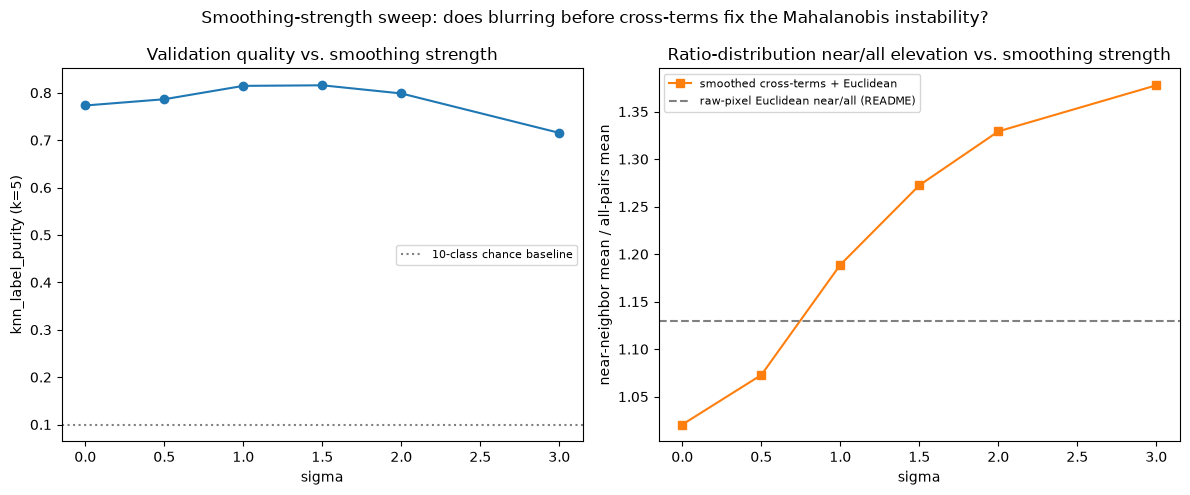

In [2]:
result = run_smoothing_sweep(sigmas=[0, 0.5, 1, 1.5, 2, 3], seed=SEED, verbose=True)
sigma_results = result["sigma_results"]
print("\ndone")

## Summary table

In [3]:
rows = []
for sigma, r in sigma_results.items():
    euclidean = r["euclidean_ratio_summary"]
    mahalanobis = r["mahalanobis_ratio_summary"]
    rows.append({
        "sigma": sigma,
        "min_cv": r["min_cv"],
        "stability_pass": r["stability_pass"],
        "selected_epsilon": r["selected_epsilon"],
        "knn_label_purity": r["knn_label_purity"],
        "euclidean_near_over_all": euclidean["near_neighbor_mean"] / euclidean["all_pairs_mean"],
        "mahalanobis_near_over_all": (mahalanobis["near_neighbor_mean"] / mahalanobis["all_pairs_mean"]) if mahalanobis else None,
    })

summary_df = pd.DataFrame(rows).set_index("sigma")
display(summary_df)

,min_cv,stability_pass,selected_epsilon,knn_label_purity,euclidean_near_over_all,mahalanobis_near_over_all
sigma,,,,,,
0.0,0.639600,False,0.0001,0.7732,1.020650,None
0.5,0.331366,False,0.0001,0.7864,1.072795,None
1.0,0.075374,False,1.0000,0.8146,1.188802,None
1.5,0.075751,False,1.0000,0.8158,1.272437,None
2.0,0.114883,False,0.0001,0.7986,1.329200,None
3.0,0.124126,False,0.1000,0.7154,1.377699,None


## Summary plots

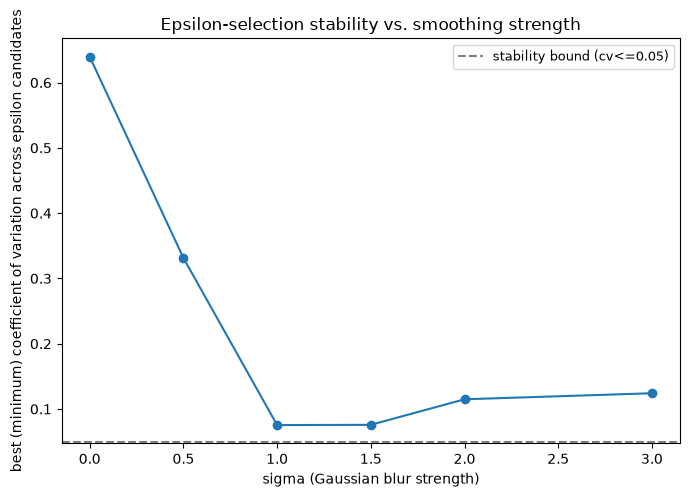

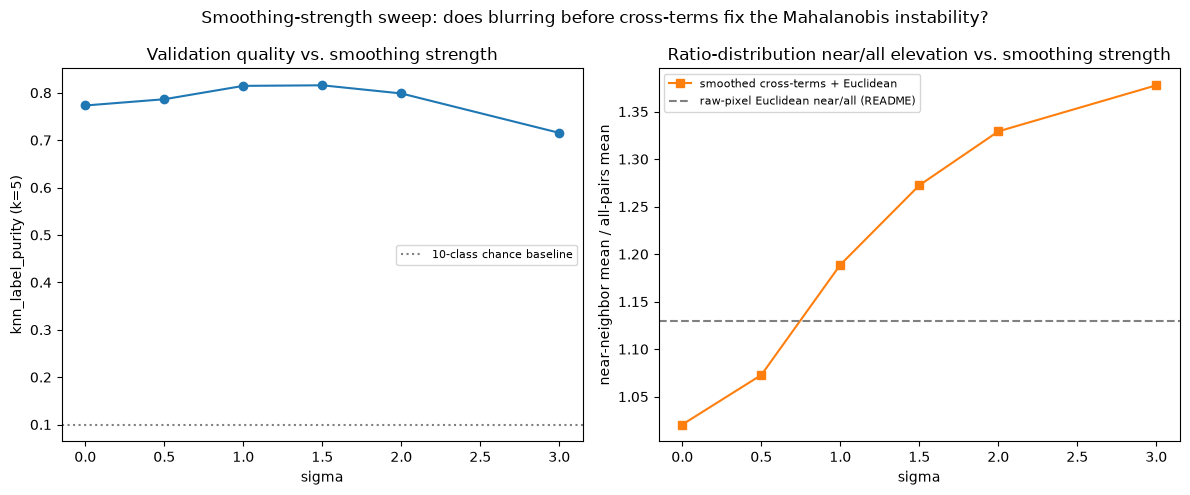

In [4]:
display(result["stability_figure"])
display(result["ratio_figure"])

## Visual sanity check: are digits still distinguishable at each sigma?

One gallery per sigma -- a fixed set of sample digits (0, 1, 3, 5, 7, 9), original vs. blurred at
that sigma.

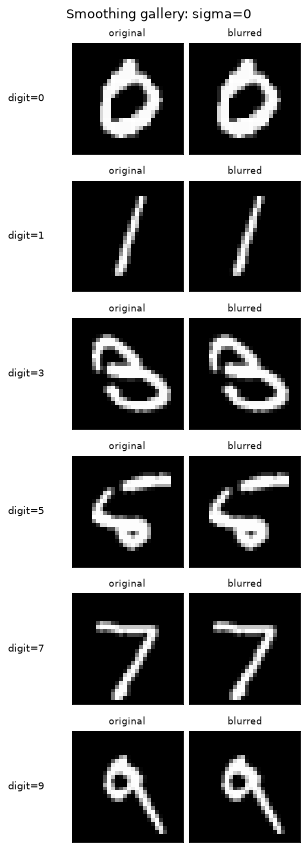

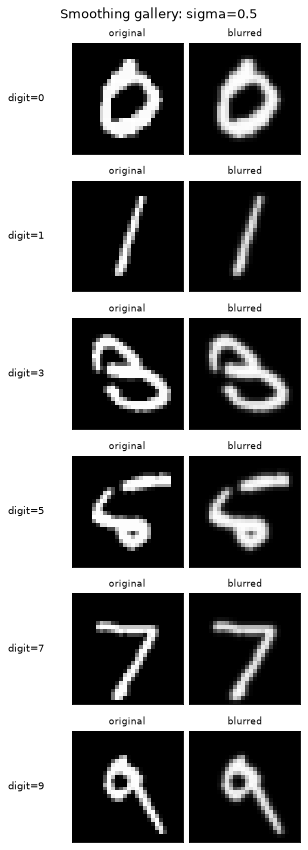

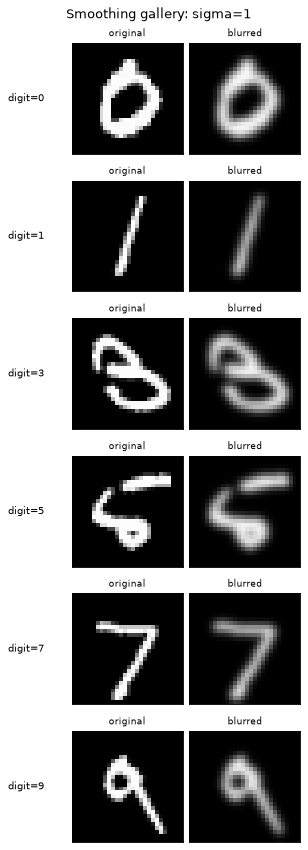

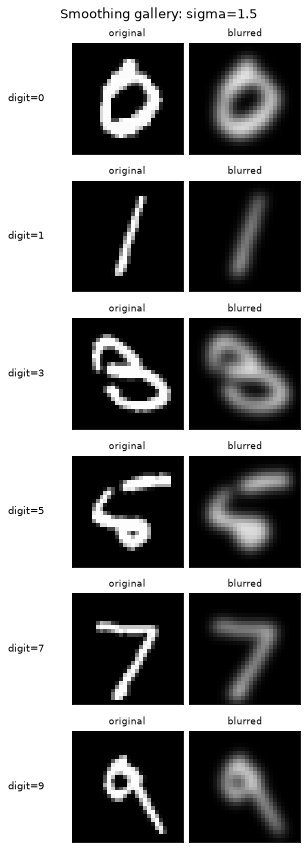

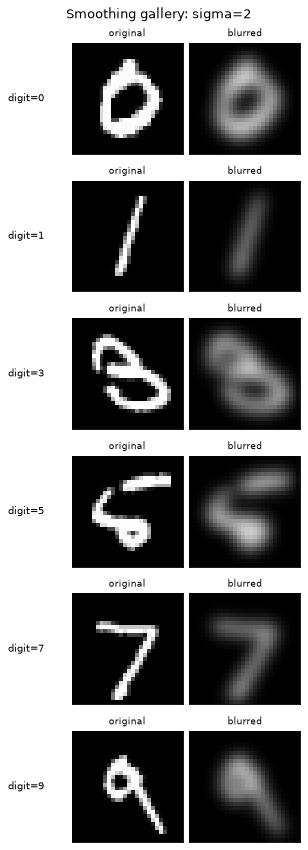

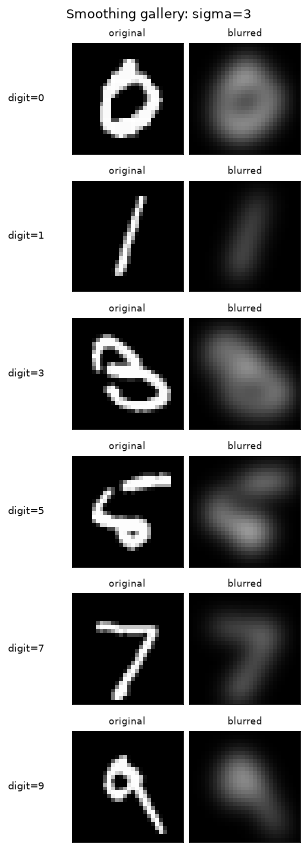

In [5]:
for sigma, r in sigma_results.items():
    display(r["gallery_figure"])

## Finding: no sigma in this range actually fixes the instability, but there's a clear near-miss

| sigma | min_cv | stability_pass (cv<=0.05) | selected_epsilon | knn_label_purity | euclidean near/all |
|---|---|---|---|---|---|
| 0 (baseline, unblurred) | 0.6396 | False | 0.0001 | 0.7732 | 1.0207 |
| 0.5 | 0.3314 | False | 0.0001 | 0.7864 | 1.0728 |
| 1   | 0.0754 | False | 1     | 0.8146 | 1.1888 |
| 1.5 | 0.0758 | False | 1     | 0.8158 | 1.2724 |
| 2   | 0.1149 | False | 0.0001 | 0.7986 | 1.3292 |
| 3   | 0.1241 | False | 0.1   | 0.7154 | 1.3777 |

**(a) Does any sigma actually pass the `cv<=0.05` stability bound?** No -- `stability_pass=False` at
every single sigma tested, 0 through 3. But smoothing is not doing nothing: `min_cv` drops **~8.5x**
from the unblurred baseline (0.6396) to its best point at `sigma=1` (0.0754), essentially a plateau
through `sigma=1.5` (0.0758), before climbing again at `sigma=2` (0.1149) and `sigma=3` (0.1241). This
is a genuine U-shaped (or more precisely, sharply-improving-then-degrading) curve, not a flat failure
-- but the *best* point reached (0.0754-0.0758) is still about 50% above the 0.05 bound, not a near-
miss close enough to call a rounding difference.

**(b) Does the near-best region (sigma~1-1.5) still preserve visual digit distinctness?** Yes, clearly.
The galleries at `sigma=1` and `sigma=1.5` (above) show every sample digit -- 0, 1, 3, 5, 7, 9 --
still immediately and unambiguously readable: softened edges, but no loss of the topological features
(the 0's hole, the 3's two lobes, the 9's loop-plus-tail) that distinguish one digit from another.
`knn_label_purity` backs this up quantitatively: it actually *peaks* in this same region (0.8146 at
sigma=1, 0.8158 at sigma=1.5 -- both higher than the unblurred baseline's 0.7732), meaning the
embedding is, if anything, slightly *more* locally class-informative here, not less. By contrast, the
`sigma=3` gallery shows real degradation -- digit 0's hole is nearly filled in, digit 3 has collapsed
toward a single blob, digit 1 is a barely-legible smear -- and `knn_label_purity` drops to 0.7154,
the lowest of the whole sweep, confirming the visual read.

**(c) Plain verdict: there is a real, measurable smoothing sweet spot (sigma~1-1.5) where the
instability is much less severe and digits are still fully legible -- but even at that best point,
epsilon selection never actually crosses into passing territory.** This is not the "stability only
kicks in after digits are already visibly degraded" failure mode -- degradation (sigma=3) and the
best-stability region (sigma=1-1.5) are clearly separated, with the good region coming *first*, well
before visual quality drops. So the hypothesis that blurring would fix the categorical instability is
**partially supported, not confirmed**: smoothing measurably helps (an 8.5x cv improvement, a purity
improvement, and a visually sound sweet spot exist), but not enough to actually flip
`local_patch_cross_terms` + Mahalanobis from "categorically unusable" to "usable" within this 0-3 sigma
range. Because `stability_pass` was `False` at every sigma, no Mahalanobis ratio-distribution numbers
were computed anywhere in this sweep (per `run_smoothing_sweep`'s design -- see its docstring) -- there
is nothing to report for that metric here, consistent with the gating logic, not a gap in the run.

**What this does and doesn't rule out**: a coarser or finer sigma grid, a different `epsilon_values`
range concentrated near the (still large) selected epsilons at sigma=1/1.5, or a larger
`epsilon_pool_size`/`n_subsamples` might push `min_cv` under 0.05 -- this sweep doesn't rule that out,
it just doesn't find it within the tested grid. The clean, reproducible U-shape (improve sharply,
plateau, then degrade) at least gives a principled place to look next: near `sigma=1-1.5`, not at the
extremes.